# 04 · Quadrant quantization and residual

Process four image regions independently, reassemble them without losing pixels, and inspect the quantization residual.

**Inputs:** two web photographs, [NASA astronaut](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut) and [coffee by Rachel Michetti](https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee). Original files, source URLs, credits, and checksums are in [assets/](assets/). Both photographs are processed at their original dimensions.

**Group:** Nmertgules and Iliya.

The figures and measurements below are saved outputs from an actual execution. Use Restart Kernel and Run All to reproduce them.

## 1. Load and verify the photographs

The repository includes the images. If this notebook is opened alone in Colab, the same files are downloaded from the versioned URLs and checked against SHA-256 hashes.

In [1]:
%matplotlib inline
from pathlib import Path
from urllib.request import urlopen
import hashlib
import json
from time import perf_counter_ns

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("png")
plt.rcParams.update({
    "figure.dpi": 95, "font.family": "DejaVu Sans", "font.size": 10,
    "axes.titlesize": 11, "figure.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False,
})
SOURCES = [{'name': 'astronaut', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/astronaut.png', 'sha256': '88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5', 'bytes': 791555, 'credit': 'NASA', 'license': 'Public domain', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.astronaut'}, {'name': 'coffee', 'url': 'https://raw.githubusercontent.com/scikit-image/scikit-image/v0.25.2/skimage/data/coffee.png', 'sha256': 'cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7', 'bytes': 466706, 'credit': 'Rachel Michetti, courtesy of Pikolo Espresso Bar', 'license': 'CC0 1.0', 'license_reference': 'https://scikit-image.org/docs/0.25.x/api/skimage.data.html#skimage.data.coffee'}]
# Works from the repository root, from week2/, and in a standalone Colab notebook.
asset_dir = next((p for p in (Path("assets"), Path("week2/assets"))
                  if p.is_dir()), Path("assets"))
asset_dir.mkdir(parents=True, exist_ok=True)
images = {}
for source in SOURCES:
    path = asset_dir / (source["name"] + ".png")
    if not path.is_file():
        with urlopen(source["url"], timeout=45) as response:
            path.write_bytes(response.read())
    raw = path.read_bytes()
    assert hashlib.sha256(raw).hexdigest() == source["sha256"], f"Photo checksum mismatch: {path.name}"
    bgr = cv2.imdecode(np.frombuffer(raw, dtype=np.uint8), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot decode photograph: {path.name}")
    images[source["name"]] = {
        "rgb": cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB),
        "gray": cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY),
    }
    print(f"Loaded {source['name']}: {bgr.shape[1]} x {bgr.shape[0]} pixels; SHA-256 verified")

def show_table(headers, rows):
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def show_image(ax, image, title, vmax=255):
    ax.imshow(image, cmap="gray" if image.ndim == 2 else None,
              vmin=0 if image.ndim == 2 else None,
              vmax=vmax if image.ndim == 2 else None, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")

def show_figure(fig):
    display(fig)
    plt.close(fig)

RESULTS = {}

Loaded astronaut: 512 x 512 pixels; SHA-256 verified
Loaded coffee: 600 x 400 pixels; SHA-256 verified


## 2. Method

The split uses midpoint slices and keeps the extra row or column for odd dimensions. Each quadrant applies floor(x/64) × 64 with a wider integer intermediate. The difference x − Q(x) is computed using signed integers and must lie between 0 and 63.

In [2]:
def quantize(image):
    return ((image.astype(np.int32) // 64) * 64).astype(np.uint8)

def split_quadrants(image):
    if min(image.shape) < 2:
        raise ValueError("Quadrant splitting requires at least 2 x 2 pixels")
    h, w = image.shape
    return [image[:h//2, :w//2], image[:h//2, w//2:],
            image[h//2:, :w//2], image[h//2:, w//2:]]

def reassemble(parts):
    return np.vstack((np.hstack(parts[:2]), np.hstack(parts[2:])))

## 3. Results on both photographs

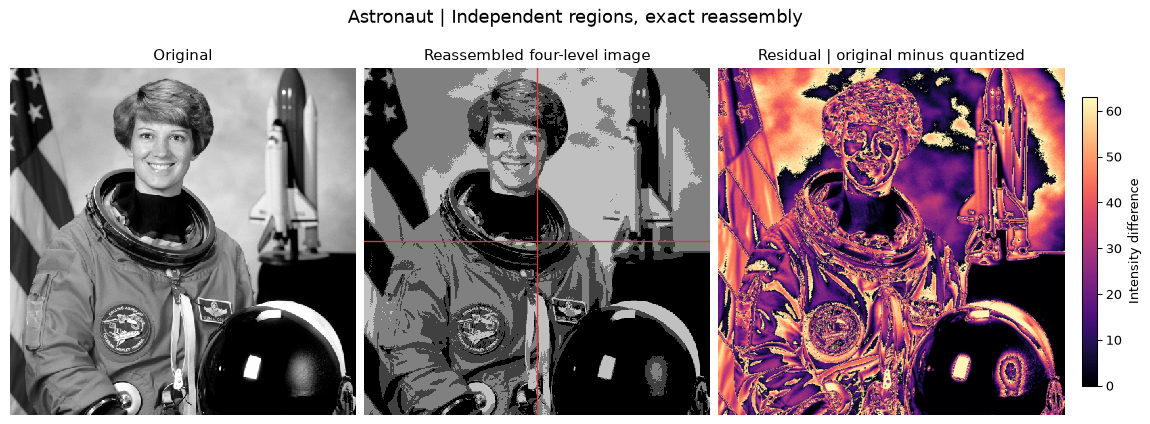

| Quadrant | Dimensions | Mean residual | Max residual |
| --- | --- | --- | --- |
| Top left | 256 x 256 | 31.721 | 63 |
| Top right | 256 x 256 | 26.953 | 63 |
| Bottom left | 256 x 256 | 29.692 | 63 |
| Bottom right | 256 x 256 | 16.537 | 63 |

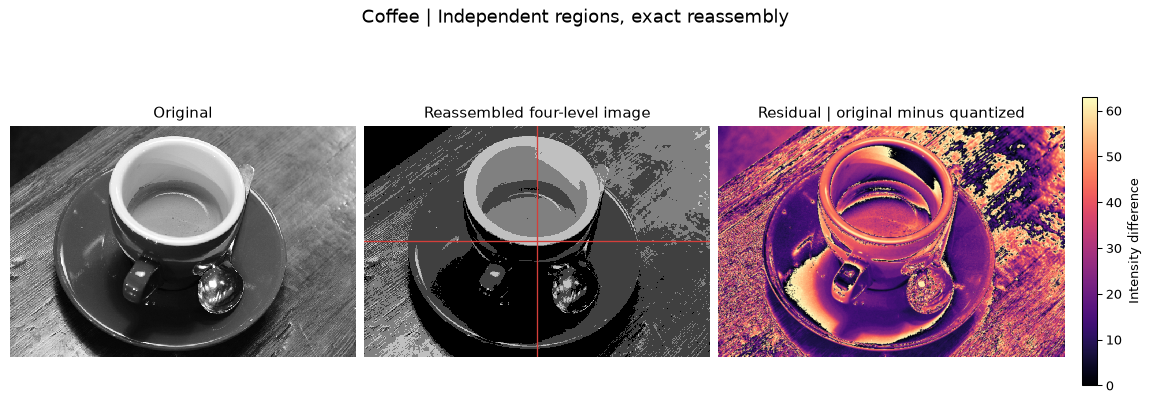

| Quadrant | Dimensions | Mean residual | Max residual |
| --- | --- | --- | --- |
| Top left | 300 x 200 | 29.874 | 63 |
| Top right | 300 x 200 | 29.876 | 63 |
| Bottom left | 300 x 200 | 26.900 | 63 |
| Bottom right | 300 x 200 | 29.146 | 63 |

In [3]:
for name, photo in images.items():
    image = photo["gray"]
    parts = split_quadrants(image)
    processed = [quantize(part) for part in parts]
    result = reassemble(processed)
    residual = image.astype(np.int16) - result.astype(np.int16)
    assert result.shape == image.shape and np.array_equal(result, quantize(image))
    assert 0 <= residual.min() <= residual.max() <= 63
    fig, axes = plt.subplots(1, 3, figsize=(12, 4.7), layout="constrained")
    show_image(axes[0], image, "Original")
    show_image(axes[1], result, "Reassembled four-level image")
    axes[1].axhline(image.shape[0]//2 - 0.5, color="#d43f3a", lw=1)
    axes[1].axvline(image.shape[1]//2 - 0.5, color="#d43f3a", lw=1)
    error_plot = axes[2].imshow(residual, cmap="magma", vmin=0, vmax=63)
    axes[2].set_title("Residual | original minus quantized")
    axes[2].axis("off")
    fig.colorbar(error_plot, ax=axes[2], shrink=0.7, label="Intensity difference")
    fig.suptitle(name.title() + " | Independent regions, exact reassembly", fontsize=14)
    show_figure(fig)
    rows = []
    for label, original, changed in zip(["Top left", "Top right", "Bottom left", "Bottom right"], parts, processed):
        difference = original.astype(np.int16) - changed.astype(np.int16)
        rows.append([label, f"{original.shape[1]} x {original.shape[0]}", f"{difference.mean():.3f}", int(difference.max())])
    show_table(["Quadrant", "Dimensions", "Mean residual", "Max residual"], rows)
    RESULTS[name] = {"shape": list(image.shape), "whole_image_equal": bool(np.array_equal(result, quantize(image))), "residual_min": int(residual.min()), "residual_max": int(residual.max()), "residual_mean": float(residual.mean())}

## 4. Interpretation

Processing regions independently gives the same pixels as processing the entire image because this operation depends only on each pixel's own intensity. The residual records discarded within-bin information. Red lines identify the split locations; they are plot annotations, not modifications to the result array.

In [4]:
for shape in [(5, 7), (2, 3), (3, 2), (2, 2)]:
    sample = np.arange(np.prod(shape), dtype=np.uint8).reshape(shape)
    assert np.array_equal(reassemble(split_quadrants(sample)), sample)
    assert np.array_equal(reassemble([quantize(p) for p in split_quadrants(sample)]), quantize(sample))
print("PASS: both photographs, residual bounds, exact reassembly, and odd-dimension cases.")

PASS: both photographs, residual bounds, exact reassembly, and odd-dimension cases.
